<a href="https://colab.research.google.com/github/joppetk/oil_spill_detection/blob/main/notebooks/UNet_%2B_DenseNet201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install scikit-learn
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip -q install rasterio albumentations==1.4.7 opencv-python matplotlib tqdm lightning==2.3.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.5/808.5 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 67.0 MB/s eta 0:00:00


In [2]:
!pip -q install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00


In [3]:
#@title ⛏️ Setup


import os, sys, math, time, json, random, pathlib
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.models.segmentation import deeplabv3_resnet101
from torchvision.transforms.functional import normalize as tv_normalize
import rasterio
import cv2
import csv
from datetime import datetime

from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.amp import GradScaler, autocast

print('Torch:', torch.__version__, 'CUDA:', torch.cuda.is_available())

Torch: 2.9.0+cu126 CUDA: True


In [4]:
#@title 🔗 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from dataclasses import dataclass, field


@dataclass
class Cfg:
    drive_root: str = '/content/drive/MyDrive'
    data_dir: str = '/content/drive/MyDrive/Sentinel SAR datasets'

    # --- TRAINING SET FOLDERS ---
    oil_img_dir: str       = 'Oil'
    oil_mask_dir: str      = 'Mask_oil'
    no_oil_img_dir: str    = 'No_oil'
    no_oil_mask_dir: str   = 'Mask_no_oil'
    look_img_dir: str      = 'Lookalike'
    look_mask_dir: str     = 'Mask_lookalike'

    # --- HOLDOUT TEST SET (optional, not used in K-fold yet) ---
    test_img_dir: str  = '02_Test_images_and_ground_truth/Images'
    test_mask_dir: str = '02_Test_images_and_ground_truth/Mask'

     # --- HOLDOUT TEST SET (optional, not used in K-fold yet) ---
    test_oil_img_dir: str  = '02_Test_images_and_ground_truth/Images/Oil'
    test_oil_mask_dir: str = '02_Test_images_and_ground_truth/Mask/Oil'
    test_no_oil_img_dir: str  = '02_Test_images_and_ground_truth/Images/No oil'
    test_no_oil_mask_dir: str = '02_Test_images_and_ground_truth/Mask/No oil'
    test_look_img_dir: str  = '02_Test_images_and_ground_truth/Images/Lookalike'
    test_look_mask_dir: str = '02_Test_images_and_ground_truth/Mask/Lookalike'

    out_dir: str = '/content/drive/MyDrive/oil_spill_checkpoints/periments/unet2ch'






    num_classes: int = 2  # background, oil
    epochs: int = 50
    batch_size: int = 8
    lr: float = 5e-4
    weight_decay: float = 1e-4
    crop_size: int = 512
    amp: bool = True
    seed: int = 1337

    # --- K-FOLD / CALIBRATION SETTINGS ---
    k_folds: int = 5
    n_bins: int = 10      # reliability bins for ECE


    log_file: str = field(init=False)

    # This method runs *after* the instance (cfg) is created
    def __post_init__(self):
        # 1. Define the full path for the log file
        #self.log_file = os.path.join(self.out_dir, "deepLab_resnet101_training_log.csv")
        #new experiment using resnet101 for oil only dataset
        self.log_file = os.path.join(self.out_dir, "unet_densenet201_training_test_data_included_in_log.csv")

        # 2. Ensure the output directory exists
        os.makedirs(self.out_dir, exist_ok=True)

        # 3. Write headers only if the file doesn't exist
        if not os.path.isfile(self.log_file):
            print(f"Creating new log file: {self.log_file}")
            with open(self.log_file, mode="w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow([
                    "timestamp", "fold", "epoch", "train_loss",
                    "val_loss", "IoU", "F1", "FAR", "ECE", "uncertainty_var", "test_iou", "test_f1"
                ])

cfg = Cfg()
os.makedirs(cfg.out_dir, exist_ok=True)


In [6]:
from typing import List, Dict

def build_training_items(cfg: Cfg) -> List[Dict]:
    """Collect all (image, mask) pairs from Oil, No_oil, Lookalike."""
    items = []

    def add_pairs(img_subdir, mask_subdir, label):
        img_dir = os.path.join(cfg.data_dir, img_subdir)
        mask_dir = os.path.join(cfg.data_dir, mask_subdir)
        assert os.path.isdir(img_dir), f"Missing folder: {img_dir}"
        assert os.path.isdir(mask_dir), f"Missing folder: {mask_dir}"

        for name in sorted(os.listdir(img_dir)):
            if not name.lower().endswith('.tif'):
                continue
            img_path = os.path.join(img_dir, name)
            base = os.path.splitext(name)[0]
            if img_subdir in (cfg.test_oil_img_dir, cfg.test_no_oil_img_dir, cfg.test_look_img_dir):
              base = base + '_segmentation'
            # mask can be .png or .tif
            mask_png = os.path.join(mask_dir, base + '.png')
            mask_tif = os.path.join(mask_dir, base + '.tif')
            if os.path.exists(mask_png):
                mask_path = mask_png
            elif os.path.exists(mask_tif):
                mask_path = mask_tif
            else:
                print(f"[WARN] No mask found for {img_path}")
                continue

            items.append({
                'img': img_path,
                'mask': mask_path,
                'subset': label,
                'name': name,
            })

    add_pairs(cfg.oil_img_dir,     cfg.oil_mask_dir,     'oil')
    add_pairs(cfg.no_oil_img_dir,  cfg.no_oil_mask_dir,  'no_oil')
    add_pairs(cfg.look_img_dir,    cfg.look_mask_dir,    'lookalike')

    add_pairs(cfg.test_oil_img_dir,   cfg.test_oil_mask_dir,    'test_oil')
    add_pairs(cfg.test_no_oil_img_dir,   cfg.test_no_oil_mask_dir,    'test_no_oil')
    add_pairs(cfg.test_look_img_dir,   cfg.test_look_mask_dir,    'test_look')

    print(f"Total training items: {len(items)} "
          f"(oil={sum(i['subset']=='oil' for i in items)}, "
          f"no_oil={sum(i['subset']=='no_oil' for i in items)}, "
          f"lookalike={sum(i['subset']=='lookalike' for i in items)})")
    return items

all_items = build_training_items(cfg)


Total training items: 2839 (oil=1200, no_oil=685, lookalike=504)


In [7]:
test_oil_items = [i for i in all_items if i['subset'] == 'test_oil']
test_no_oil_items = [i for i in all_items if i['subset'] == 'test_no_oil']
test_look_items = [i for i in all_items if i['subset'] == 'test_look']
print(test_oil_items[0])

{'img': '/content/drive/MyDrive/Sentinel SAR datasets/02_Test_images_and_ground_truth/Images/Oil/00000.tif', 'mask': '/content/drive/MyDrive/Sentinel SAR datasets/02_Test_images_and_ground_truth/Mask/Oil/00000_segmentation.tif', 'subset': 'test_oil', 'name': '00000.tif'}


In [8]:
class OilSpillDataset(Dataset):
    def __init__(self, items, crop_size=512, augment=True):
        """
        items: list of dicts with keys ['img', 'mask', 'subset', 'name']
        """
        self.items = items
        self.crop = crop_size
        self.augment = augment

    def __len__(self):
        return len(self.items)

    def _read_tiff_2ch(self, path):
        with rasterio.open(path) as ds:
            arr = ds.read()  # (C,H,W) or (H,W)
        # Force to 2 bands [VV, VH]
        if arr.ndim == 3 and arr.shape[0] >= 2:
            arr = arr[:2]
        elif arr.ndim == 3 and arr.shape[0] == 1:
            arr = np.concatenate([arr, arr], 0)
        elif arr.ndim == 2:
            arr = np.stack([arr, arr], 0)
        else:
            raise ValueError(f"Unexpected TIFF shape {arr.shape} for {path}")
        arr = np.transpose(arr, (1,2,0)).astype(np.float32)  # (H,W,2)
        return arr

    def _read_mask(self, path):
        if path.lower().endswith('.tif') or path.lower().endswith('.tiff'):
            with rasterio.open(path) as ds:
                m = ds.read(1)
        else:
            m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        m = (m > 0).astype(np.uint8)   # binary 0/1
        return m

    def _random_crop(self, img, mask, size):
        H,W,_ = img.shape
        if H < size or W < size:
            pad_h, pad_w = max(0, size-H), max(0, size-W)
            img  = cv2.copyMakeBorder(img,  0, pad_h, 0, pad_w, cv2.BORDER_REFLECT_101)
            mask = cv2.copyMakeBorder(mask, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)
            H,W,_ = img.shape
        y = random.randint(0, H-size)
        x = random.randint(0, W-size)
        return img[y:y+size, x:x+size], mask[y:y+size, x:x+size]

    '''def _augs(self, img, mask):
        # only for training
        if self.augment:
            if random.random() < 0.5:
                img  = np.ascontiguousarray(np.fliplr(img))
                mask = np.ascontiguousarray(np.fliplr(mask))
            if random.random() < 0.5:
                img  = np.ascontiguousarray(np.flipud(img))
                mask = np.ascontiguousarray(np.flipud(mask))
        return img, mask'''

    def _augs(self, img, mask):
        if self.augment:
            # Horizontal flip
            if random.random() < 0.5:
                img  = np.ascontiguousarray(np.fliplr(img))
                mask = np.ascontiguousarray(np.fliplr(mask))

            # Vertical flip
            if random.random() < 0.5:
                img  = np.ascontiguousarray(np.flipud(img))
                mask = np.ascontiguousarray(np.flipud(mask))

            # 90-degree rotations (0,90,180,270)
            if random.random() < 0.5:
                k = random.choice([1, 2, 3])  # 90,180,270
                img  = np.ascontiguousarray(np.rot90(img,  k, axes=(0,1)))
                mask = np.ascontiguousarray(np.rot90(mask, k, axes=(0,1)))

            # Small Gaussian noise (SAR-like speckle)
            if random.random() < 0.3:
                noise = np.random.normal(0, 0.05, img.shape).astype(np.float32)
                img = img + noise
                img = np.clip(img, -5.0, 5.0)  # keep in a reasonable range

            # Slight contrast/brightness jitter
            if random.random() < 0.3:
                alpha = 1.0 + 0.2 * (2*random.random() - 1)  # 0.8–1.2
                beta  = 0.1 * (2*random.random() - 1)        # -0.1–0.1
                img = alpha * img + beta
        return img, mask

    def __getitem__(self, idx):
        item = self.items[idx]
        img_path  = item['img']
        mask_path = item['mask']

        img  = self._read_tiff_2ch(img_path)
        mask = self._read_mask(mask_path)

        # normalize each channel (same as your training code)
        img = np.clip(img, -50, 5)
        img = (img - (-22.5)) / 12.5

        img, mask = self._augs(img, mask)
        if self.crop:
            img, mask = self._random_crop(img, mask, self.crop)

        img = np.transpose(img, (2,0,1))  # CHW
        return torch.from_numpy(img), torch.from_numpy(mask).long()


In [9]:
import torch
import torch.nn as nn

import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class UNetDictOut(nn.Module):
    """
    Wrap SMP UNet so your existing code can keep using:
        out = model(x)['out']
    """
    def __init__(self, in_channels=2, num_classes=2, encoder_name="densenet201",
                 encoder_weights="imagenet", dropout_p=0.0):
        super().__init__()
        self.net = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,   # ImageNet pretrained
            in_channels=in_channels,           # <-- 2ch VV,VH
            classes=num_classes,               # <-- 2 classes
            activation=None                    # logits
        )
        # Optional dropout for MC-dropout later (set dropout_p>0 to enable)
        self.drop = nn.Dropout2d(dropout_p) if dropout_p and dropout_p > 0 else nn.Identity()

    def forward(self, x):
        logits = self.net(x)          # (B,C,H,W)
        logits = self.drop(logits)    # optional
        return {"out": logits}

# build the model
# NOTE: DenseNet201 is heavy; if you OOM at 512 crops + batch 8, reduce batch size.
model = UNetDictOut(
    in_channels=2,
    num_classes=cfg.num_classes,
    encoder_name="densenet201",
    encoder_weights="imagenet",
    dropout_p=0.0,       # set to 0.1~0.3 if you want MC Dropout variance later
).to(device)

# Cross-Entropy only (as requested)
ce = nn.CrossEntropyLoss()

def loss_fn(logits, targets):
    return ce(logits, targets)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/81.1M [00:00<?, ?B/s]

In [10]:
def build_model(cfg):
    return UNetDictOut(
        in_channels=2,
        num_classes=cfg.num_classes,
        encoder_name="densenet201",
        encoder_weights="imagenet",
        dropout_p=0.0,   # set >0 only if you want MC-dropout uncertainty
    )


In [11]:
import numpy as np

def validate_with_calibration(
    model,
    val_loader,
    device,
    n_bins=10,
    ignore_index=255
):
    model.eval()
    ce_loss = 0.0
    total_px = 0

    # confusion
    TP = FP = TN = FN = 0

    # calibration stats
    bin_total = np.zeros(n_bins, dtype=np.float64)
    bin_conf_sum = np.zeros(n_bins, dtype=np.float64)
    bin_correct = np.zeros(n_bins, dtype=np.float64)
    uncertainty_sum = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)['out']  # (B,2,H,W)
            loss = ce(logits, y)      # re-use your CE part
            ce_loss += loss.item() * x.size(0)

            # probs and predictions
            probs = torch.softmax(logits, dim=1)[:,1]  # foreground prob
            preds = (probs >= 0.5).long()              # binary pred (0/1)

            # flatten
            p_flat = probs.detach().cpu().numpy().ravel()
            y_flat = y.detach().cpu().numpy().ravel()
            pr_flat = preds.detach().cpu().numpy().ravel()

            if ignore_index is not None:
                valid = (y_flat != ignore_index)
                p_flat = p_flat[valid]
                y_flat = y_flat[valid]
                pr_flat = pr_flat[valid]

            if p_flat.size == 0:
                continue

            total_px += p_flat.size

            # confusion
            TP += np.sum((pr_flat == 1) & (y_flat == 1))
            FP += np.sum((pr_flat == 1) & (y_flat == 0))
            TN += np.sum((pr_flat == 0) & (y_flat == 0))
            FN += np.sum((pr_flat == 0) & (y_flat == 1))

            # calibration bins
            bin_idx = np.minimum((p_flat * n_bins).astype(int), n_bins-1)
            for b in range(n_bins):
                m = (bin_idx == b)
                if not np.any(m):
                    continue
                bin_total[b]    += m.sum()
                bin_conf_sum[b] += p_flat[m].sum()
                bin_correct[b]  += np.sum(pr_flat[m] == y_flat[m])

            # uncertainty p(1-p)
            uncertainty_sum += np.sum(p_flat * (1.0 - p_flat))

    # normalize losses & metrics
    ce_loss /= max(1, len(val_loader.dataset))

    IoU = TP / max(1, (TP + FP + FN))
    precision = TP / max(1, (TP + FP))
    recall = TP / max(1, (TP + FN))
    if precision + recall > 0:
        F1 = 2 * precision * recall / (precision + recall)
    else:
        F1 = 0.0

    FAR = FP / max(1, (FP + TN))

    # ECE + reliability diagram
    ece = 0.0
    bin_acc = np.zeros(n_bins, dtype=np.float64)
    bin_conf = np.zeros(n_bins, dtype=np.float64)
    if total_px > 0:
        for b in range(n_bins):
            if bin_total[b] == 0:
                bin_acc[b] = np.nan
                bin_conf[b] = np.nan
                continue
            bin_acc[b] = bin_correct[b] / bin_total[b]
            bin_conf[b] = bin_conf_sum[b] / bin_total[b]
            weight = bin_total[b] / total_px
            ece += weight * abs(bin_acc[b] - bin_conf[b])

    uncertainty_var = uncertainty_sum / max(1, total_px)

    metrics_out = {
        'loss': ce_loss,
        'IoU': float(IoU),
        'F1': float(F1),
        'FAR': float(FAR),
        'ECE': float(ece),
        'uncertainty_var': float(uncertainty_var),
        'TP': int(TP),
        'FP': int(FP),
        'TN': int(TN),
        'FN': int(FN),
        'bin_conf': bin_conf,
        'bin_acc': bin_acc,
        'bin_total': bin_total,
    }
    return metrics_out


In [12]:
import numpy as np

def validate_with_calibration(
    model,
    val_loader,
    device,
    n_bins=10,
    ignore_index=255
):
    model.eval()
    ce_loss = 0.0
    total_px = 0

    # confusion
    TP = FP = TN = FN = 0

    # calibration stats
    bin_total = np.zeros(n_bins, dtype=np.float64)
    bin_conf_sum = np.zeros(n_bins, dtype=np.float64)
    bin_correct = np.zeros(n_bins, dtype=np.float64)
    uncertainty_sum = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)['out']  # (B,2,H,W)
            loss = ce(logits, y)      # re-use your CE part
            ce_loss += loss.item() * x.size(0)

            # probs and predictions
            probs = torch.softmax(logits, dim=1)[:,1]  # foreground prob
            preds = (probs >= 0.5).long()              # binary pred (0/1)

            # flatten
            p_flat = probs.detach().cpu().numpy().ravel()
            y_flat = y.detach().cpu().numpy().ravel()
            pr_flat = preds.detach().cpu().numpy().ravel()

            if ignore_index is not None:
                valid = (y_flat != ignore_index)
                p_flat = p_flat[valid]
                y_flat = y_flat[valid]
                pr_flat = pr_flat[valid]

            if p_flat.size == 0:
                continue

            total_px += p_flat.size

            # confusion
            TP += np.sum((pr_flat == 1) & (y_flat == 1))
            FP += np.sum((pr_flat == 1) & (y_flat == 0))
            TN += np.sum((pr_flat == 0) & (y_flat == 0))
            FN += np.sum((pr_flat == 0) & (y_flat == 1))

            # calibration bins
            bin_idx = np.minimum((p_flat * n_bins).astype(int), n_bins-1)
            for b in range(n_bins):
                m = (bin_idx == b)
                if not np.any(m):
                    continue
                bin_total[b]    += m.sum()
                bin_conf_sum[b] += p_flat[m].sum()
                bin_correct[b]  += np.sum(pr_flat[m] == y_flat[m])

            # uncertainty p(1-p)
            uncertainty_sum += np.sum(p_flat * (1.0 - p_flat))

    # normalize losses & metrics
    ce_loss /= max(1, len(val_loader.dataset))

    IoU = TP / max(1, (TP + FP + FN))
    precision = TP / max(1, (TP + FP))
    recall = TP / max(1, (TP + FN))
    if precision + recall > 0:
        F1 = 2 * precision * recall / (precision + recall)
    else:
        F1 = 0.0

    FAR = FP / max(1, (FP + TN))

    # ECE + reliability diagram
    ece = 0.0
    bin_acc = np.zeros(n_bins, dtype=np.float64)
    bin_conf = np.zeros(n_bins, dtype=np.float64)
    if total_px > 0:
        for b in range(n_bins):
            if bin_total[b] == 0:
                bin_acc[b] = np.nan
                bin_conf[b] = np.nan
                continue
            bin_acc[b] = bin_correct[b] / bin_total[b]
            bin_conf[b] = bin_conf_sum[b] / bin_total[b]
            weight = bin_total[b] / total_px
            ece += weight * abs(bin_acc[b] - bin_conf[b])

    uncertainty_var = uncertainty_sum / max(1, total_px)

    metrics_out = {
        'loss': ce_loss,
        'IoU': float(IoU),
        'F1': float(F1),
        'FAR': float(FAR),
        'ECE': float(ece),
        'uncertainty_var': float(uncertainty_var),
        'TP': int(TP),
        'FP': int(FP),
        'TN': int(TN),
        'FN': int(FN),
        'bin_conf': bin_conf,
        'bin_acc': bin_acc,
        'bin_total': bin_total,
    }
    return metrics_out


In [ ]:


from sklearn.model_selection import KFold
from torch.amp import GradScaler, autocast
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

kfold = KFold(n_splits=cfg.k_folds, shuffle=True, random_state=cfg.seed)
fold_summaries = []

#VV-only run
#cfg.in_channels = 1
#RESUME = False

#VV+VH- run
cfg.in_channels = 2
#RESUME = False

RESUME = False  # set False if you ever want to force retraining

for fold, (train_idx, val_idx) in enumerate(kfold.split(all_items), start=1):
    print('='*80)
    print(f'📚 Fold {fold}/{cfg.k_folds}')
    print('='*80)

    train_items = [all_items[i] for i in train_idx]
    val_items   = [all_items[i] for i in val_idx]

    train_ds = OilSpillDataset(train_items, crop_size=cfg.crop_size, augment=True)
    val_ds   = OilSpillDataset(val_items,   crop_size=cfg.crop_size, augment=False)

    #train_ds = OilSpillDataset(train_items, crop_size=512, augment=True,  vv_only=True)
    #val_ds   = OilSpillDataset(val_items,   crop_size=512, augment=False, vv_only=True)

    # Balanced sampler for training
    target_probs = {
        'oil': 0.5,
        'no_oil': 0.25,
        'lookalike': 0.25
    }
    #train_sampler = BalancedOilSampler(train_items, target_probs=target_probs)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, #sampler=train_sampler,   # <-- use sampler
                              shuffle=True, # <-- True when not using use sampler
                              num_workers=2, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)


    ckpt_path = os.path.join(cfg.out_dir, f'unet_densenet201_oil_fold{fold}_best.pt')

    ft_ckpt_path = os.path.join(cfg.out_dir,    f'unet_densenet201_oil_fold{fold}_ft_best.pt')
    ckpt_path = ft_ckpt_path

    # --- model / optimizer / scheduler ---
    model = build_model(cfg).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)
    #sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100)

    scaler = GradScaler('cuda', enabled=cfg.amp)

    # --- default start (fresh) ---
    start_epoch = 1
    best_iou = -1.0
    best_metrics = None

    # --- RESUME: if we already have a best checkpoint for this fold ---
    if RESUME and os.path.exists(ckpt_path):
        print(f"🔁 Resuming fold {fold} from {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)


        # load weights
        state = ckpt.get('state_dict', ckpt)
        state = {k.replace('module.', ''): v for k, v in state.items()}
        model.load_state_dict(state, strict=True)

        # get last best epoch & IoU
        prev_epoch = ckpt.get('epoch', 0)
        best_metrics = ckpt.get('metrics', {})
        best_iou = best_metrics.get('IoU', -1.0)
        #best_iou = 0.5
        start_epoch = prev_epoch + 1

        print(f"  last best epoch={prev_epoch}, best IoU={best_iou:.4f}")

        # Optional: if we already finished all epochs for this fold, skip it
        if start_epoch > cfg.epochs:
            print(f"  Fold {fold} already finished (start_epoch={start_epoch} > {cfg.epochs}), skipping.")
            fold_summaries.append({
                'fold': fold,
                'best_IoU':   best_iou,
                'best_F1':    best_metrics.get('F1', 0.0),
                'best_FAR':   best_metrics.get('FAR', 0.0),
                'best_ECE':   best_metrics.get('ECE', 0.0),
                'best_Uvar':  best_metrics.get('uncertainty_var', 0.0),
            })
            continue

    # --- main training loop for this fold ---
    for epoch in range(start_epoch, cfg.epochs+1):
        # -------- TRAIN --------
        model.train()
        tr_loss = 0.0
        for x,y in tqdm(train_loader, desc=f'Fold {fold} Epoch {epoch}/{cfg.epochs} [train]'):
            x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast('cuda', enabled=cfg.amp):
                out = model(x)['out']
                loss = loss_fn(out, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            tr_loss += loss.item() * x.size(0)
        tr_loss /= max(1, len(train_loader.dataset))
        sched.step()

        # -------- VALIDATE + CALIBRATION --------
        val_metrics = validate_with_calibration(
            model, val_loader, device, n_bins=cfg.n_bins, ignore_index=255
        )

        print(
            f"Fold {fold} Epoch {epoch:03d} | "
            f"train {tr_loss:.4f} | "
            f"val_loss {val_metrics['loss']:.4f} | "
            f"IoU {val_metrics['IoU']:.4f} | "
            f"F1 {val_metrics['F1']:.4f} | "
            f"FAR {val_metrics['FAR']:.4f} | "
            f"ECE {val_metrics['ECE']:.4f} | "
            f"U_var {val_metrics['uncertainty_var']:.4f}"
        )

        with open(cfg.log_file, mode="a", newline="") as f:
          writer = csv.writer(f)
          writer.writerow([
              datetime.now().isoformat(timespec="seconds"),
              fold,
              epoch,
              f"{tr_loss:.4f}",
              f"{val_metrics['loss']:.4f}",
              f"{val_metrics['IoU']:.4f}",
              f"{val_metrics['F1']:.4f}",
              f"{val_metrics['FAR']:.4f}",
              f"{val_metrics['ECE']:.4f}",
              f"{val_metrics['uncertainty_var']:.4f}"
          ])


        # track best by IoU
        if val_metrics['IoU'] > best_iou:
            best_iou = val_metrics['IoU']
            best_metrics = val_metrics
            torch.save({
                'state_dict': model.state_dict(),
                'cfg': vars(cfg),
                'fold': fold,
                'epoch': epoch,
                'metrics': best_metrics
            }, ft_ckpt_path)
            print(f"  ✅ New best fold {fold} IoU={best_iou:.4f} saved to {ft_ckpt_path}")

    # Store summary for this fold (best_metrics from latest / resumed run)
    fold_summaries.append({
        'fold': fold,
        'best_IoU':   best_metrics['IoU'],
        'best_F1':    best_metrics['F1'],
        'best_FAR':   best_metrics['FAR'],
        'best_ECE':   best_metrics['ECE'],
        'best_Uvar':  best_metrics['uncertainty_var'],
    })
    print(f"Fold {fold} best: IoU={best_metrics['IoU']:.4f}, "
          f"F1={best_metrics['F1']:.4f}, FAR={best_metrics['FAR']:.4f}, "
          f"ECE={best_metrics['ECE']:.4f}, Uvar={best_metrics['uncertainty_var']:.4f})")




Using device: cuda
📚 Fold 1/5


Fold 1 Epoch 1/50 [train]:   0%|          | 0/283 [00:00<?, ?it/s]WARNING:rasterio._env:CPLE_AppDefined in 00318.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Fold 1 Epoch 1/50 [train]: 100%|██████████| 283/283 [23:23<00:00,  4.96s/it]
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has 

Fold 1 Epoch 001 | train 0.1515 | val_loss 0.1037 | IoU 0.0001 | F1 0.0001 | FAR 0.0000 | ECE 0.9099 | U_var 0.0545
  ✅ New best fold 1 IoU=0.0001 saved to /content/drive/MyDrive/oil_spill_checkpoints/periments/unet2ch/unet_densenet201_oil_fold1_ft_best.pt


Fold 1 Epoch 2/50 [train]:   0%|          | 0/283 [00:00<?, ?it/s]WARNING:rasterio._env:CPLE_AppDefined in 00642.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Fold 1 Epoch 2/50 [train]: 100%|██████████| 283/283 [24:23<00:00,  5.17s/it]
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has 

Fold 1 Epoch 002 | train 0.0808 | val_loss 0.0655 | IoU 0.1818 | F1 0.3077 | FAR 0.0163 | ECE 0.9481 | U_var 0.0243
  ✅ New best fold 1 IoU=0.1818 saved to /content/drive/MyDrive/oil_spill_checkpoints/periments/unet2ch/unet_densenet201_oil_fold1_ft_best.pt


Fold 1 Epoch 3/50 [train]:   0%|          | 0/283 [00:00<?, ?it/s]WARNING:rasterio._env:CPLE_AppDefined in 00948.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Fold 1 Epoch 3/50 [train]: 100%|██████████| 283/283 [23:26<00:00,  4.97s/it]
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has 

Fold 1 Epoch 003 | train 0.0700 | val_loss 0.0651 | IoU 0.0706 | F1 0.1319 | FAR 0.0148 | ECE 0.9528 | U_var 0.0186


Fold 1 Epoch 4/50 [train]:   0%|          | 0/283 [00:00<?, ?it/s]WARNING:rasterio._env:CPLE_AppDefined in 00532.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Fold 1 Epoch 4/50 [train]: 100%|██████████| 283/283 [23:20<00:00,  4.95s/it]
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has 

Fold 1 Epoch 004 | train 0.0653 | val_loss 0.0606 | IoU 0.1865 | F1 0.3143 | FAR 0.0146 | ECE 0.9574 | U_var 0.0160
  ✅ New best fold 1 IoU=0.1865 saved to /content/drive/MyDrive/oil_spill_checkpoints/periments/unet2ch/unet_densenet201_oil_fold1_ft_best.pt


Fold 1 Epoch 5/50 [train]:   0%|          | 0/283 [00:00<?, ?it/s]WARNING:rasterio._env:CPLE_AppDefined in 00460.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Fold 1 Epoch 5/50 [train]:  81%|████████▏ | 230/283 [19:14<03:29,  3.95s/it]WARNING:rasterio._env:CPLE_AppDefined in 00496.tif: TIFFReadDirectory:Sum of Photometric type-related co

===========INFERENCE================

In [13]:
test_oil_items = [i for i in all_items if i['subset'] == 'test_oil']
test_no_oil_items = [i for i in all_items if i['subset'] == 'test_no_oil']
test_look_items = [i for i in all_items if i['subset'] == 'test_look']
print(test_oil_items[1])

{'img': '/content/drive/MyDrive/Sentinel SAR datasets/02_Test_images_and_ground_truth/Images/Oil/00001.tif', 'mask': '/content/drive/MyDrive/Sentinel SAR datasets/02_Test_images_and_ground_truth/Mask/Oil/00001_segmentation.tif', 'subset': 'test_oil', 'name': '00001.tif'}


In [23]:

ckpt_path = "/content/drive/My Drive/oil_spill_checkpoints/periments/unet2ch/unet_densenet201_oil_fold5_ft_best.pt"   #for 5 ====

model = build_model(cfg).to(device)
ckpt  = torch.load(ckpt_path, map_location=device, weights_only=False)
state = ckpt.get("state_dict", ckpt)
state = {k.replace("module.", ""): v for k,v in state.items()}
model.load_state_dict(state, strict=True)
model.eval()


UNetDictOut(
  (net): Unet(
    (encoder): DenseNetEncoder(
      (features): Sequential(
        (conv0): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu0): ReLU(inplace=True)
        (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (denseblock1): _DenseBlock(
          (denselayer1): _DenseLayer(
            (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu1): ReLU(inplace=True)
            (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu2): ReLU(inplace=True)
            (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          )
          (denselayer2): _DenseLayer(


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, jaccard_score

def compute_iou_f1(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    iou = jaccard_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")
    return iou, f1


# ----- Expected Calibration Error -----
def compute_ece(probs, labels, n_bins=15):
    """
    probs: (H,W) probability map 0-1
    labels: (H,W) GT 0/1
    """
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() == 0:
            continue
        avg_conf = probs[mask].mean()
        avg_acc  = labels[mask].mean()
        ece += (mask.sum() / probs.size) * abs(avg_conf - avg_acc)
    return ece


def plot_reliability_diagram(probs, labels, n_bins=15):
    bins = np.linspace(0, 1, n_bins+1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    accs = []
    confs = []
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() == 0:
            accs.append(np.nan)
            confs.append(np.nan)
        else:
            confs.append(probs[mask].mean())
            accs.append(labels[mask].mean())

    plt.figure(figsize=(4,4))
    plt.plot([0,1],[0,1],'k--',label="Perfect calibration")
    plt.plot(confs, accs, marker='o')
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title("Reliability Diagram")
    plt.grid(True)
    plt.show()


def compute_far(y_true, y_pred):
    """
    False Alarm Rate = FP / (FP + TN)
    y_true, y_pred: (H,W) binary 0/1
    """
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    denom = fp + tn
    if denom == 0:
        return 0.0
    return fp / denom


def viz_batch_metrics(x, y, pred_logits, thr=0.3, show_metrics=True):
    x = x.detach().cpu().numpy()
    if y.ndim == 4: y = y.squeeze(1)
    y = y.detach().cpu().numpy()

    # 1-channel sigmoid vs 2-class softmax
    if pred_logits.shape[1] == 1:
        probs = torch.sigmoid(pred_logits).squeeze(1).cpu().numpy()  # B,H,W
        pred  = (probs > thr).astype(np.uint8)
    else:
        probs = torch.softmax(pred_logits, dim=1)[:,1,:,:].cpu().numpy()  # class-1 prob
        pred  = torch.argmax(pred_logits, dim=1).cpu().numpy()            # B,H,W

    b = min(3, x.shape[0])

    for i in range(b):
        vv = x[i,0]; vh = x[i,1]
        vv_norm = (vv - vv.min())/(vv.max()-vv.min()+1e-6)
        vh_norm = (vh - vh.min())/(vh.max()-vh.min()+1e-6)

        # ----- images -----
        plt.figure(figsize=(14,4))
        plt.subplot(1,5,1); plt.imshow(vv_norm, cmap='gray'); plt.title('VV'); plt.axis('off')
        plt.subplot(1,5,2); plt.imshow(vh_norm, cmap='gray'); plt.title('VH'); plt.axis('off')
        plt.subplot(1,5,3); plt.imshow(y[i],  cmap='gray');  plt.title('GT Mask'); plt.axis('off')
        plt.subplot(1,5,4); plt.imshow(pred[i], cmap='gray');plt.title('Pred Mask'); plt.axis('off')
        plt.subplot(1,5,5); plt.imshow((pred[i]>0)&(y[i]==0), cmap='Reds')
        plt.title('False Positives'); plt.axis('off')
        plt.show()

        if show_metrics:
            iou, f1 = compute_iou_f1(y[i], pred[i])
            far     = compute_far(y[i], pred[i])
            ece     = compute_ece(probs[i], y[i])

            print(f"Image {i}:")
            print(f"  IoU: {iou:.4f}")
            print(f"  F1 : {f1:.4f}")
            print(f"  FAR: {far:.4f}")
            print(f"  ECE: {ece:.4f}")

            # reliability plot
            plot_reliability_diagram(probs[i], y[i])


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


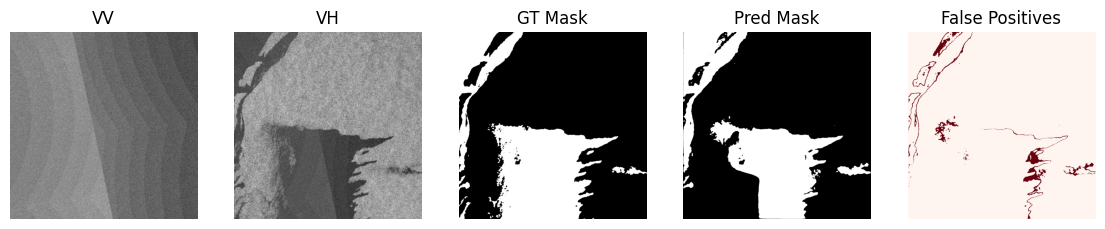

Image 0:
  IoU: 0.7365
  F1 : 0.8483
  FAR: 0.0405
  ECE: 0.0835


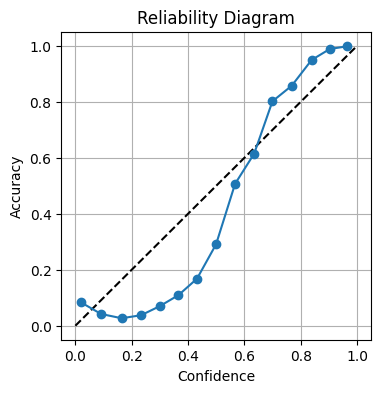

In [28]:
# Choose which test item to inspect
val_items = [test_oil_items[14]]

# No cropping, no augmentation for qualitative inspection
val_ds = OilSpillDataset(val_items, crop_size=None, augment=False)

from torch.utils.data import DataLoader

model.eval()  # important: eval mode
with torch.no_grad():  # no gradients during evaluation
    for x, y in DataLoader(val_ds, batch_size=1, shuffle=False):
        x = x.to(device); y = y.to(device)
        out = model(x)['out']          # logits
        viz_batch_metrics(x, y, out, thr=0.5, show_metrics=True)
        break  # only one image in this dataset
